# Baseline: ConvNeXt-Base for Rice Leaf Disease Classification
**Config:** ImageNet-1K pretrained | GELU activation | Stochastic Depth | ImageNet normalization
**Model:** ConvNeXt-Base (same architecture as Wang et al. 2023)

Dataset: [Rice Leaf Disease Identification Dataset](https://www.kaggle.com/datasets/wangxiaoqii/rice-leaf-disease-identification-dataset)

## 0. Colab Setup (jalankan sekali per session)

In [1]:
# ── Step 1: mount google drive (save.pt) ──
from google.colab import drive
drive.mount('/content/drive')

# Buat folder output di Drive
import os
DRIVE_DIR = '/content/drive/MyDrive/rice-convnext'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Drive folder ready: {DRIVE_DIR}')

Mounted at /content/drive
Drive folder ready: /content/drive/MyDrive/rice-convnext


In [2]:
# ── Step 2: Setup Kaggle API ──
from google.colab import files
print('Upload kaggle.json sekarang...')
files.upload()

import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle API ready')

Upload kaggle.json sekarang...


Saving kaggle.json to kaggle.json
Kaggle API ready!


In [3]:
# ── Step 3: Download & extract dataset ──
DATASET_DIR = '/content/drive/MyDrive/rice-convnext/dataset'

if os.path.exists(DATASET_DIR) and len(os.listdir(DATASET_DIR)) > 0:
    print(f'Dataset sudah ada di {DATASET_DIR}, skip download.')
else:
    print('Downloading dataset dari Kaggle...')
    !pip install kaggle -q
    !kaggle datasets download -d wangxiaoqii/rice-leaf-disease-identification-dataset \
        -p /content/tmp_dataset

    print('Extracting...')
    !unzip -q /content/tmp_dataset/*.zip -d {DATASET_DIR}
    !rm -rf /content/tmp_dataset
    print(f'Dataset ready di: {DATASET_DIR}')

# Preview struktur folder
for root, dirs, files_list in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 1:
        print(f'{indent}  ({len(files_list)} files)')
    if level > 1:
        break

Dataset URL: https://www.kaggle.com/datasets/wangxiaoqii/rice-leaf-disease-identification-dataset
License(s): unknown
100% 2.55G/2.55G [00:16<00:00, 165MB/s]

Extracting...
Dataset ready di: /content/drive/MyDrive/rice-convnext/dataset
dataset/
  Bacterial Blight/
    (0 files)
    Bacterial Blight/


## 1. Setup & Imports

In [4]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


## 2. Configuration

In [5]:
# =============================================
# CONFIG — ubah sesuai path dataset kamu
# =============================================

# Path dataset — sesuai hasil Step 3 di atas
DATA_DIR  = '/content/drive/MyDrive/rice-convnext/dataset'
DRIVE_DIR = '/content/drive/MyDrive/rice-convnext'

IMG_SIZE     = 224
BATCH_SIZE   = 16
NUM_EPOCHS   = 30
LR_INIT      = 2.5e-4
LR_FINAL     = 1e-6
WEIGHT_DECAY = 0.05
NUM_WORKERS  = 2

# ImageNet normalization stats (same as Wang et al. 2023)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Simpan .pt langsung ke Drive agar tidak hilang saat session mati
SAVE_PATH = f'{DRIVE_DIR}/convnext_base_baseline.pt'

## 3. Data Loading & Augmentation

In [6]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Load full dataset dulu, lalu split manual
full_dataset = datasets.ImageFolder(DATA_DIR)
CLASS_NAMES  = full_dataset.classes
NUM_CLASSES  = len(CLASS_NAMES)

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Total images: {len(full_dataset)}')

# Split 60:20:20 — fixed seed agar semua eksperimen pakai split sama
total = len(full_dataset)
n_train = int(0.6 * total)
n_val   = int(0.2 * total)
n_test  = total - n_train - n_val

generator = torch.Generator().manual_seed(SEED)
train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test], generator=generator
)

# Apply transforms
train_set.dataset.transform = train_transforms
val_set.dataset.transform   = val_test_transforms
test_set.dataset.transform  = val_test_transforms

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}')

Classes (7): ['Bacterial Blight', 'Bacterial Leaf Streak', 'Brown Spot', 'Healthy', 'Hispa', 'Leaf Blast', 'Sheath Blight']
Total images: 3353
Train: 2011 | Val: 670 | Test: 672


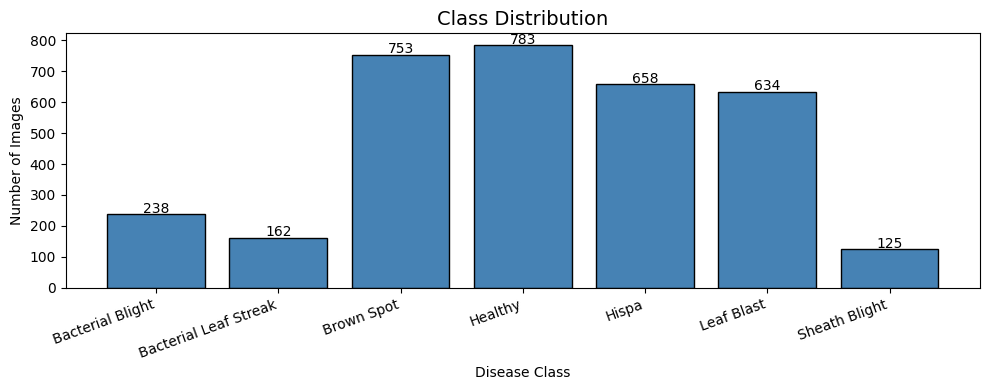

In [7]:
# Visualisasi distribusi kelas
from collections import Counter

labels = [full_dataset.targets[i] for i in range(len(full_dataset))]
label_counts = Counter(labels)
counts = [label_counts[i] for i in range(NUM_CLASSES)]

plt.figure(figsize=(10, 4))
bars = plt.bar(CLASS_NAMES, counts, color='steelblue', edgecolor='black')
plt.title('Class Distribution', fontsize=14)
plt.xlabel('Disease Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=20, ha='right')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

## 4. Model Setup — ConvNeXt-Tiny (Baseline)

In [8]:
# ConvNeXt-Base, pretrained ImageNet-1K
# Block composition: (3,3,27,3) — same as Wang et al. 2023
# Activation: GELU (default ConvNeXt)
# Regularization: Stochastic Depth (default ConvNeXt)

model = models.convnext_base(weights=models.ConvNeXt_Base_Weights.IMAGENET1K_V1)

# Ganti classifier head sesuai jumlah kelas
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)

model = model.to(DEVICE)

# Hitung total parameter
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Model: ConvNeXt-Base (88M params)')

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:01<00:00, 224MB/s]


Total parameters    : 87,573,639
Trainable parameters: 87,573,639
Model: ConvNeXt-Base (88M params)


## 5. Training Setup

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR_INIT,
    weight_decay=WEIGHT_DECAY
)

# Cosine annealing dengan warmup (1 epoch)
def get_scheduler(optimizer, num_epochs, lr_init, lr_final):
    warmup = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.01, end_factor=1.0, total_iters=1)
    cosine = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs-1, eta_min=lr_final)
    return optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[1])

scheduler = get_scheduler(optimizer, NUM_EPOCHS, LR_INIT, LR_FINAL)

## 6. Training Loop

In [10]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total


# Training
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Simpan model terbaik
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)

    print(f'Epoch [{epoch+1:02d}/{NUM_EPOCHS}] '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}'
          + (' ← best' if val_acc == best_val_acc else ''))

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')
print(f'Model saved to: {SAVE_PATH}')

Epoch [01/30] Train Loss: 1.7921 Acc: 0.2725 | Val Loss: 1.5847 Acc: 0.4373 ← best
Epoch [02/30] Train Loss: 0.6576 Acc: 0.7678 | Val Loss: 0.3486 Acc: 0.8881 ← best
Epoch [03/30] Train Loss: 0.3222 Acc: 0.8941 | Val Loss: 0.4378 Acc: 0.8358
Epoch [04/30] Train Loss: 0.1877 Acc: 0.9398 | Val Loss: 0.3344 Acc: 0.8910 ← best
Epoch [05/30] Train Loss: 0.1219 Acc: 0.9627 | Val Loss: 0.2969 Acc: 0.9284 ← best
Epoch [06/30] Train Loss: 0.0938 Acc: 0.9717 | Val Loss: 0.2371 Acc: 0.9284 ← best
Epoch [07/30] Train Loss: 0.1345 Acc: 0.9597 | Val Loss: 0.4286 Acc: 0.8940
Epoch [08/30] Train Loss: 0.1147 Acc: 0.9667 | Val Loss: 0.3264 Acc: 0.9194
Epoch [09/30] Train Loss: 0.0401 Acc: 0.9906 | Val Loss: 0.2435 Acc: 0.9418 ← best
Epoch [10/30] Train Loss: 0.0402 Acc: 0.9896 | Val Loss: 0.2083 Acc: 0.9537 ← best
Epoch [11/30] Train Loss: 0.0611 Acc: 0.9801 | Val Loss: 0.3360 Acc: 0.9104
Epoch [12/30] Train Loss: 0.0510 Acc: 0.9846 | Val Loss: 0.2335 Acc: 0.9373
Epoch [13/30] Train Loss: 0.0243 Acc: 0

## 7. Training Curves

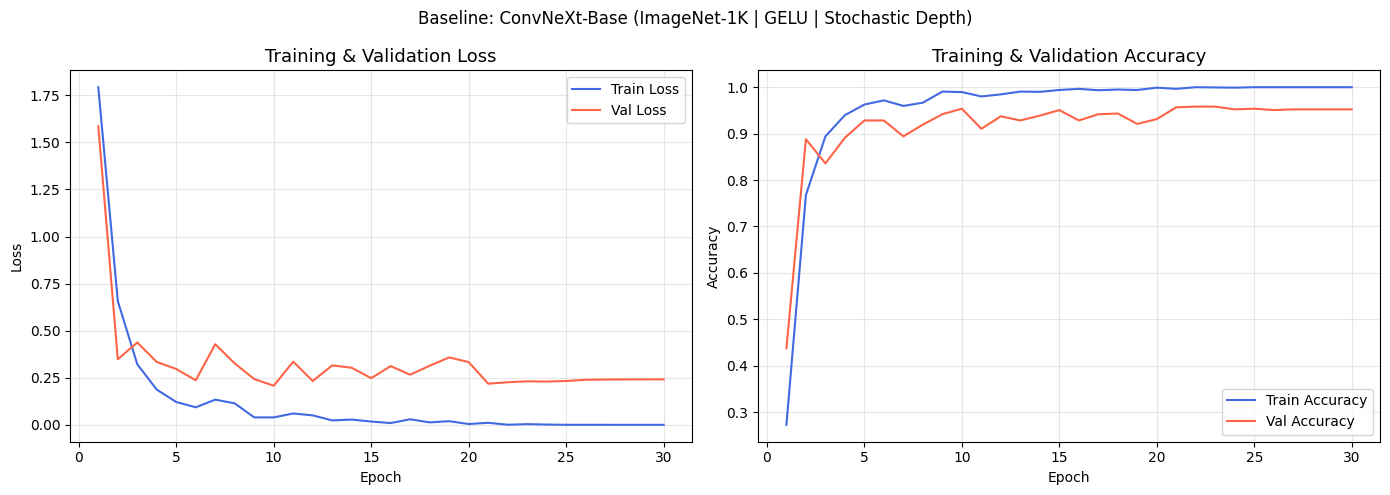

In [11]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='royalblue')
axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Training & Validation Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs, history['train_acc'], label='Train Accuracy', color='royalblue')
axes[1].plot(epochs, history['val_acc'],   label='Val Accuracy',   color='tomato')
axes[1].set_title('Training & Validation Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Baseline: ConvNeXt-Base (ImageNet-1K | GELU | Stochastic Depth)', fontsize=12)
plt.tight_layout()
plt.savefig('baseline_training_curves.png', dpi=150)
plt.show()

## 8. Evaluation on Test Set

In [12]:
# Load best model
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification report
report = classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
print('=== Classification Report ===')
print(report_df.round(4).to_string())

# Simpan tabel
report_df.to_csv('baseline_classification_report.csv')

=== Classification Report ===
                       precision  recall  f1-score   support
Bacterial Blight          0.9423  0.9074    0.9245   54.0000
Bacterial Leaf Streak     0.9615  0.8929    0.9259   28.0000
Brown Spot                0.9565  0.9277    0.9419  166.0000
Healthy                   0.9643  0.9759    0.9701  166.0000
Hispa                     0.9558  0.9818    0.9686  110.0000
Leaf Blast                0.9113  0.9187    0.9150  123.0000
Sheath Blight             0.8214  0.9200    0.8679   25.0000
accuracy                  0.9435  0.9435    0.9435    0.9435
macro avg                 0.9304  0.9321    0.9306  672.0000
weighted avg              0.9441  0.9435    0.9435  672.0000


In [ ]:
# Summary table — untuk paper
summary = {
    'Model': ['ConvNeXt-Base (Baseline)'],
    'Init Weight': ['ImageNet-1K'],
    'Activation': ['GELU'],
    'Dropout': ['Stochastic Depth'],
    'Accuracy': [report['accuracy']],
    'Precision': [report['weighted avg']['precision']],
    'Recall': [report['weighted avg']['recall']],
    'F1-Score': [report['weighted avg']['f1-score']],
}

summary_df = pd.DataFrame(summary)
print('\n=== Summary Table ===')
print(summary_df.round(4).to_string(index=False))
summary_df.to_csv('results_summary.csv', index=False)

## 9. Confusion Matrix

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cmap='Blues',
    linewidths=0.5
)
plt.title('Confusion Matrix — Baseline ConvNeXt-Base', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()

## 10. Output Files Summary

In [ ]:
import shutil

# File yang di-generate lokal → copy ke Drive
local_outputs = [
    'baseline_training_curves.png',
    'baseline_confusion_matrix.png',
    'baseline_classification_report.csv',
    'results_summary.csv',
    'class_distribution.png',
]

for fname in local_outputs:
    if os.path.exists(fname):
        shutil.copy(fname, f'{DRIVE_DIR}/{fname}')

# Checklist
all_outputs = [
    (f'{DRIVE_DIR}/convnext_base_baseline.pt',         'Model weights (.pt)'),
    (f'{DRIVE_DIR}/baseline_training_curves.png',      'Graf loss & accuracy'),
    (f'{DRIVE_DIR}/baseline_confusion_matrix.png',     'Confusion matrix'),
    (f'{DRIVE_DIR}/baseline_classification_report.csv','Tabel per-class metrics'),
    (f'{DRIVE_DIR}/results_summary.csv',               'Summary table untuk paper'),
    (f'{DRIVE_DIR}/class_distribution.png',            'Distribusi kelas dataset'),
]

print('=== Output Files (Google Drive) ===')
for fpath, desc in all_outputs:
    exists = '✅' if os.path.exists(fpath) else '❌'
    print(f'{exists}  {os.path.basename(fpath):<45} {desc}')

print(f'\nSemua file ada di: {DRIVE_DIR}')

=== Output Files (tersimpan di Google Drive) ===
✅  convnext_base_baseline.pt                     Model weights (.pt)
✅  baseline_training_curves.png                  Graf loss & accuracy
✅  baseline_confusion_matrix.png                 Confusion matrix
✅  baseline_classification_report.csv            Tabel per-class metrics
✅  results_summary.csv                           Summary table untuk paper
✅  class_distribution.png                        Distribusi kelas dataset

Semua file ada di: /content/drive/MyDrive/rice-convnext
